In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
data = {
    "Temperature": [28,29,30,31,32,33,34,30,29,31,
                    32,33,35,34,30,28,27,29,31,32,
                    33,34,35,30,28,29,32,33,34,35],

    "Students": [400,450,500,550,600,650,700,480,520,580,
                 620,680,750,720,500,420,380,460,560,610,
                 670,710,780,490,430,470,630,690,730,800],

    "Working_Hours": [6,7,8,9,10,11,12,8,7,9,
                      10,11,12,12,8,6,5,7,9,10,
                      11,12,12,8,6,7,10,11,12,12],

    "Lab_Usage": [2,3,3,4,5,6,7,3,4,5,
                  6,7,8,7,3,2,2,3,5,6,
                  7,8,9,3,2,4,6,7,8,9],

    "AC_Usage": [10,12,14,16,18,20,22,15,13,17,
                 19,21,24,23,14,10,9,12,16,18,
                 20,23,25,13,10,12,19,21,24,26],

    "Energy_Consumption": [520,590,670,750,840,930,1030,650,610,780,
                           870,970,1120,1080,630,500,460,570,760,850,
                           950,1060,1180,620,510,600,890,990,1110,1250]
}

df = pd.DataFrame(data)

print("Campus Energy Dataset Created Successfully!")
print("Number of Rows:", len(df))
print("Number of Columns:", len(df.columns))

Campus Energy Dataset Created Successfully!
Number of Rows: 30
Number of Columns: 6


In [5]:
print("Campus Energy Consumption Dataset:")
print(df)

Campus Energy Consumption Dataset:
    Temperature  Students  Working_Hours  Lab_Usage  AC_Usage  \
0            28       400              6          2        10   
1            29       450              7          3        12   
2            30       500              8          3        14   
3            31       550              9          4        16   
4            32       600             10          5        18   
5            33       650             11          6        20   
6            34       700             12          7        22   
7            30       480              8          3        15   
8            29       520              7          4        13   
9            31       580              9          5        17   
10           32       620             10          6        19   
11           33       680             11          7        21   
12           35       750             12          8        24   
13           34       720             12          7    

In [6]:
print("Dataset Information:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column Names:")
print(df.columns.tolist())

Dataset Information:
Rows: 30
Columns: 6
Column Names:
['Temperature', 'Students', 'Working_Hours', 'Lab_Usage', 'AC_Usage', 'Energy_Consumption']


In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Temperature           0
Students              0
Working_Hours         0
Lab_Usage             0
AC_Usage              0
Energy_Consumption    0
dtype: int64


In [8]:
print("Statistical Summary of Dataset:")
print(df.describe())

Statistical Summary of Dataset:
       Temperature    Students  Working_Hours  Lab_Usage   AC_Usage  \
count    30.000000   30.000000      30.000000  30.000000  30.000000   
mean     31.366667  584.333333       9.266667   5.133333  17.200000   
std       2.370557  121.816236       2.227312   2.239663   5.054189   
min      27.000000  380.000000       5.000000   2.000000   9.000000   
25%      29.250000  482.500000       7.250000   3.000000  13.000000   
50%      31.500000  590.000000       9.500000   5.000000  17.500000   
75%      33.000000  687.500000      11.000000   7.000000  21.000000   
max      35.000000  800.000000      12.000000   9.000000  26.000000   

       Energy_Consumption  
count           30.000000  
mean           811.333333  
std            228.061294  
min            460.000000  
25%            612.500000  
50%            810.000000  
75%            985.000000  
max           1250.000000  


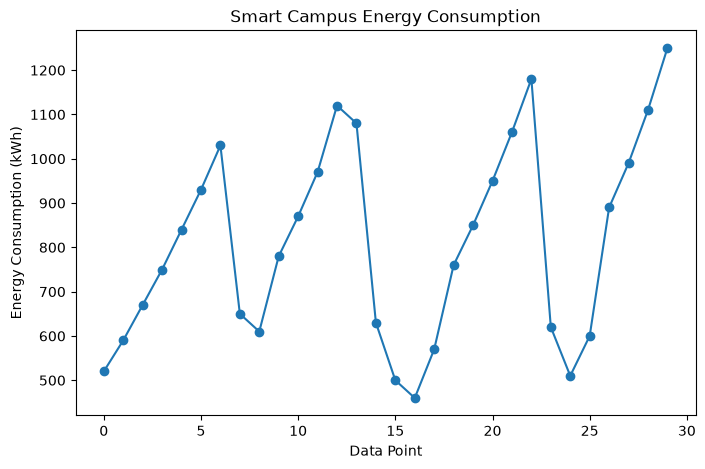

Energy Consumption Graph Displayed Successfully!


In [9]:
plt.figure(figsize=(8,5))

plt.plot(df["Energy_Consumption"], marker="o")

plt.xlabel("Data Point")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Smart Campus Energy Consumption")

plt.show()

print("Energy Consumption Graph Displayed Successfully!")

In [10]:
X = df[[
    "Temperature",
    "Students",
    "Working_Hours",
    "Lab_Usage",
    "AC_Usage"
]]

y = df["Energy_Consumption"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Energy_Consumption")

Input Features:
['Temperature', 'Students', 'Working_Hours', 'Lab_Usage', 'AC_Usage']

Target Variable:
Energy_Consumption


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Splitting Completed Successfully!")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Data Splitting Completed Successfully!
Training Samples: 24
Testing Samples: 6


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Random Forest Regression Model Trained Successfully!")

Random Forest Regression Model Trained Successfully!


In [14]:
y_pred = model.predict(X_test_scaled)

print("Predicted Energy Consumption:")
print(y_pred)

Predicted Energy Consumption:
[974.4        515.1        640.73333333 597.2        617.51333333
 782.7       ]


In [15]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):")
print(round(mae, 2))

Mean Absolute Error (MAE):
14.81


In [16]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):")
print(round(rmse, 2))

Root Mean Squared Error (RMSE):
16.86


In [17]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:")
print(round(r2, 4))

R2 Score:
0.9893


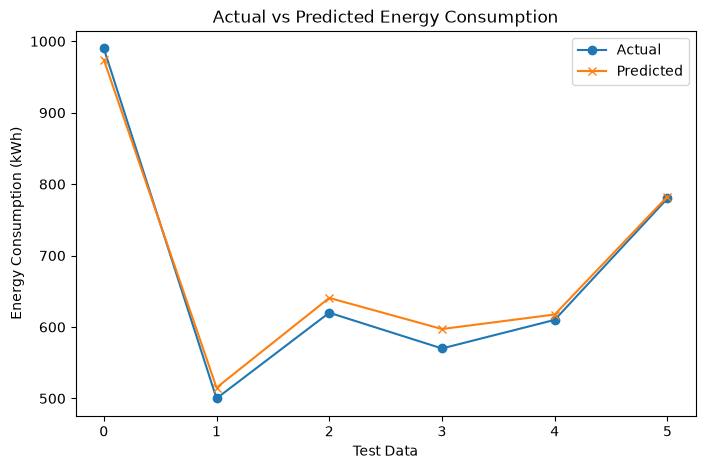

Actual vs Predicted Graph Displayed Successfully!


In [18]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, marker="o", label="Actual")
plt.plot(y_pred, marker="x", label="Predicted")

plt.xlabel("Test Data")
plt.ylabel("Energy Consumption (kWh)")
plt.title("Actual vs Predicted Energy Consumption")

plt.legend()
plt.show()

print("Actual vs Predicted Graph Displayed Successfully!")

In [19]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

print("Feature Importance:")
print(importance.sort_values(ascending=False))

Feature Importance:
AC_Usage         0.249990
Temperature      0.216360
Students         0.216020
Working_Hours    0.175682
Lab_Usage        0.141948
dtype: float64


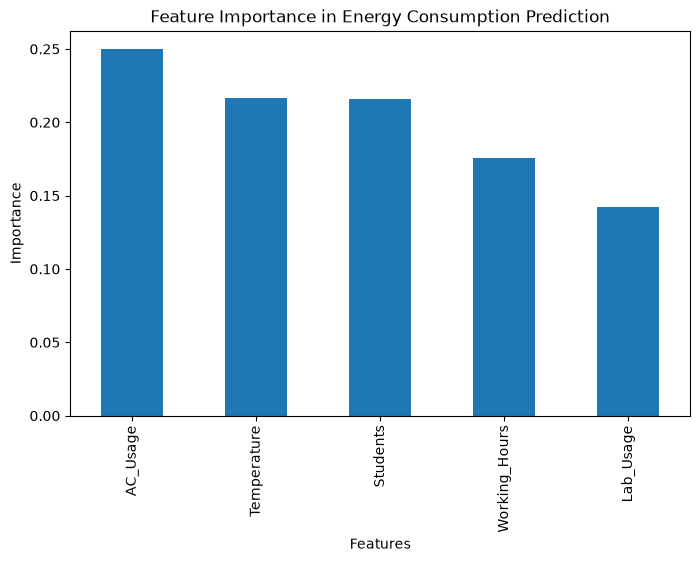

Feature Importance Graph Displayed Successfully!


In [20]:
importance.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Energy Consumption Prediction")

plt.show()

print("Feature Importance Graph Displayed Successfully!")

In [21]:
new_data = pd.DataFrame(
    [[31, 650, 10, 6, 20]],
    columns=X.columns
)

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("New Campus Data:")
print("Temperature: 31 °C")
print("Students: 650")
print("Working Hours: 10")
print("Lab Usage: 6")
print("AC Usage: 20")

print("\nPredicted Energy Consumption:",
      round(prediction[0], 2), "kWh")

New Campus Data:
Temperature: 31 °C
Students: 650
Working Hours: 10
Lab Usage: 6
AC Usage: 20

Predicted Energy Consumption: 869.3 kWh
